# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [I Komang Galih Agustan]
- **Email:** [galihagustan2@gmail.com]
- **ID Dicoding:** [Galihagustansukidayo]

## Menentukan Pertanyaan Bisnis

- Produk dan kategori produk apa yang menghasilkan total pendapatan tertinggi?
- produk dan kategori produk apa yang paling sering dibeli pada masing masing wilayah?
- wilayah mana yang memiliki volume transaksi tertinggi dan bagaimana kontribusinya terhadap total penjualan

## Import Semua Packages/Library yang Digunakan

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip freeze > requirements.txt

In [128]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Wrangling

### Gathering Data

In [129]:
df_list_customers = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_customers_dataset.csv")
df_list_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [130]:
df_list_geolocation = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_geolocation_dataset.csv")
df_list_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [131]:
df_list_orderitem = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_order_items_dataset.csv")
df_list_orderitem.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [132]:
df_list_payments = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_order_payments_dataset.csv")
df_list_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [133]:
df_list_order_reviews = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_order_reviews_dataset.csv")
df_list_order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [134]:
df_list_orders = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_orders_dataset.csv")
df_list_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [135]:
df_list_products = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_products_dataset.csv")
df_list_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [136]:
df_list_sellers = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/olist_sellers_dataset.csv")
df_list_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [137]:
df_list_product_category = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/E-Commerce/product_category_name_translation.csv")
df_list_product_category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Merging

In [138]:
# orders dengan order items
df_orders_items = df_list_orders.merge(df_list_orderitem, on='order_id', how='left')

# info pembayaran
df_orders_items = df_orders_items.merge(df_list_payments, on='order_id', how='left')

# info pelanggan
df_orders_items = df_orders_items.merge(df_list_customers, on='customer_id', how='left')

# info produk
df_orders_items = df_orders_items.merge(df_list_products, on='product_id', how='left')

# terjemahan kategori produk
df_orders_items = df_orders_items.merge(df_list_product_category, on='product_category_name', how='left')

# info penjual
df_orders_items = df_orders_items.merge(df_list_sellers, on='seller_id', how='left')


In [139]:
df_orders_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP


In [140]:
df_orders_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   order_item_id                  117604 non-null  float64
 9   product_id                     117604 non-null  object 
 10  seller_id                      117604 non-null  object 
 11  shipping_limit_date            117604 non-null  object 
 12  price                         

In [141]:
df_orders_items.describe()

,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix
count,117604.000000,117604.000000,117604.000000,118431.000000,118431.000000,118431.000000,118434.000000,115906.000000,115906.000000,115906.000000,117584.000000,117584.000000,117584.00000,117584.000000,117604.000000
mean,1.195920,120.822849,20.045551,1.094207,2.937398,172.849395,35034.264392,48.767208,786.957302,2.207849,2114.281067,30.256872,16.63029,23.068394,24442.886483
std,0.697721,184.477367,15.861351,0.728290,2.774164,268.259831,29819.290218,10.035162,653.029009,1.719519,3788.754048,16.190874,13.45878,11.748372,27573.802989
min,1.000000,0.850000,0.000000,1.000000,0.000000,0.000000,1003.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.00000,6.000000,1001.000000
25%,1.000000,39.900000,13.080000,1.000000,1.000000,60.860000,11310.000000,42.000000,347.000000,1.000000,300.000000,18.000000,8.00000,15.000000,6429.000000
50%,1.000000,74.900000,16.290000,1.000000,2.000000,108.200000,24240.000000,52.000000,601.000000,1.000000,700.000000,25.000000,13.00000,20.000000,13660.000000
75%,1.000000,134.900000,21.190000,1.000000,4.000000,189.245000,58464.500000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.00000,30.000000,28035.000000
max,21.000000,6735.000000,409.680000,29.000000,24.000000,13664.080000,99990.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.00000,118.000000,99730.000000


**Insight:**
- order_item_id dengan rata rata 1.19 dan maximum 21 berarti sebagian besar order itu dikisaran 1 item tapi ada pesanan sangat banyak hingga 21 item. kemungkinan ada pelanggan premium
- pada kolom price diketahui bahwa ada produk yang sangat murah yakni 0.85 dan produk sangat mahal (6735). kategori produk sangat beragam
- payment_installments rata rata 3 kali cicilan dan max 24 kali yang artinya banyak pelanggan masih mencicil untuk transaksi
- payment_value memiliki rata rata 172 dan max 13.664. sebagian besar transaksinya kecil hingga menengah tetapi adapun transaksi yang sangat besar
- produk sangat beragam, bisa dilihat dari product weight dengan median 700 g hingga maximum 400 g dengan rata rata 2000g/2kg.

### Assessing Data

cek missing value


In [142]:
df_orders_items.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,176
order_delivered_carrier_date,2074
order_delivered_customer_date,3397
order_estimated_delivery_date,0
order_item_id,830
product_id,830


cek nilai unik

In [143]:
for col in df_orders_items.columns:
    print(f"Kolom: {col}")
    print(df_orders_items[col].unique()[:10])
    print("Jumlah unik:", df_orders_items[col].nunique())
    print("-"*50)


Kolom: order_id
['e481f51cbdc54678b7cc49136f2d6af7' '53cdb2fc8bc7dce0b6741e2150273451'
 '47770eb9100c2d0c44946d9cf07ec65d' '949d5b44dbf5de918fe9c16f97b45f8a'
 'ad21c59c0840e6cb83a9ceb5573f8159' 'a4591c265e18cb1dcee52889e2d8acc3'
 '136cce7faa42fdb2cefd53fdc79a6098' '6514b8ad8028c9f2cc2374ded245783f'
 '76c6e866289321a7c93b82b54852dc33' 'e69bfb5eb88e0ed6a785585b27e16dbf']
Jumlah unik: 99441
--------------------------------------------------
Kolom: customer_id
['9ef432eb6251297304e76186b10a928d' 'b0830fb4747a6c6d20dea0b8c802d7ef'
 '41ce2a54c0b03bf3443c3d931a367089' 'f88197465ea7920adcdbec7375364d82'
 '8ab97904e6daea8866dbdbc4fb7aad2c' '503740e9ca751ccdda7ba28e9ab8f608'
 'ed0271e0b7da060a393796590e7b737a' '9bdf08b4b3b52b5526ff42d37d47f222'
 'f54a9f0e6b351c431402b8461ea51999' '31ad1d1b63eb9962463f764d4e6e0c9d']
Jumlah unik: 99441
--------------------------------------------------
Kolom: order_status
['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved'

invalid value


In [144]:
df_orders_items[df_orders_items['payment_value']<=0]
df_orders_items[df_orders_items['freight_value']<0]
df_orders_items[df_orders_items['product_weight_g']<=0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
6055,06afc1144eb9f51ef2aa90ec9223c7f4,e8be078dee76002545a9c5f10b7d7c4e,delivered,2018-08-15 17:13:07,2018-08-15 17:25:20,2018-08-16 14:44:00,2018-08-24 22:54:42,2018-09-20 00:00:00,1.0,e673e90efa65a5409ff4196c038bb5af,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
6056,06afc1144eb9f51ef2aa90ec9223c7f4,e8be078dee76002545a9c5f10b7d7c4e,delivered,2018-08-15 17:13:07,2018-08-15 17:25:20,2018-08-16 14:44:00,2018-08-24 22:54:42,2018-09-20 00:00:00,2.0,e673e90efa65a5409ff4196c038bb5af,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
15179,4abc7b5330425bcf9c2f7f48151a88c0,d1568f1104d2015dc70bdf7d9ab88dd2,delivered,2018-07-31 21:05:49,2018-07-31 21:40:18,2018-08-01 16:00:00,2018-08-07 23:56:48,2018-08-17 00:00:00,1.0,8038040ee2a71048d4bdbbdc985b69ab,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
46797,200b121c28e10ef638131a7c76753327,26bcca10e5c9679c306d8333bf527929,delivered,2018-08-04 15:55:59,2018-08-04 16:10:16,2018-08-08 14:35:00,2018-08-23 18:21:59,2018-08-30 00:00:00,1.0,81781c0fed9fe1ad6e8c81fca1e1cb08,...,529.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
77602,476b812a7e4fc972646eb390517bddcb,18a1176652a9344ba489fa4ccaa3c20f,delivered,2018-08-18 11:09:12,2018-08-18 11:30:54,2018-08-21 12:07:00,2018-08-30 16:56:44,2018-09-12 00:00:00,1.0,e673e90efa65a5409ff4196c038bb5af,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
108918,b489f7ae130ba3fd26b0a20f8cc81c61,99411e9599f8b7a90f2a362b874b66ca,delivered,2018-08-18 20:37:22,2018-08-18 20:49:57,2018-08-20 14:20:00,2018-08-27 14:52:02,2018-09-04 00:00:00,1.0,e673e90efa65a5409ff4196c038bb5af,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
116773,06d9e69034388abf6da64378e10737b8,afef0047e43944e8c6630ec0d0f7de2e,delivered,2018-07-30 10:42:40,2018-07-31 09:10:11,2018-07-31 14:24:00,2018-08-09 22:18:29,2018-09-10 00:00:00,1.0,36ba42dd187055e1fbe943b2d11430ca,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP
116774,06d9e69034388abf6da64378e10737b8,afef0047e43944e8c6630ec0d0f7de2e,delivered,2018-07-30 10:42:40,2018-07-31 09:10:11,2018-07-31 14:24:00,2018-08-09 22:18:29,2018-09-10 00:00:00,2.0,36ba42dd187055e1fbe943b2d11430ca,...,528.0,1.0,0.0,30.0,25.0,30.0,bed_bath_table,14940.0,ibitinga,SP


In [145]:
invalid_data = df_orders_items[
    (df_orders_items['order_delivered_customer_date'] < df_orders_items['order_purchase_timestamp'])
]
invalid_data2 = df_orders_items[
    (df_orders_items['order_delivered_carrier_date'] < df_orders_items['order_approved_at'])
]
invalid_data3 = df_orders_items[
    (df_orders_items['order_delivered_customer_date'] < df_orders_items['order_delivered_carrier_date'])
]

print("Panjang invalid_data 1:", len(invalid_data))
print("Panjang invalid_data 2:", len(invalid_data2))
print("Panjang invalid_data 3:", len(invalid_data3))


Panjang invalid_data 1: 0
Panjang invalid_data 2: 1600
Panjang invalid_data 3: 59


In [146]:
invalid_price = df_orders_items[df_orders_items['price'] <= 0]
invalid_freight = df_orders_items[df_orders_items['freight_value'] < 0]
invalid_payment = df_orders_items[df_orders_items['payment_value'] <= 0]

print(len(invalid_price), len(invalid_freight), len(invalid_payment))


0 0 9


cek value duplicated


In [147]:
df_orders_items.duplicated().sum()

np.int64(0)

In [148]:
df_orders_items.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object
order_item_id,float64
product_id,object


cek outlier

In [149]:
Q1 = df_orders_items['price'].quantile(0.25)
Q3 = df_orders_items['price'].quantile(0.75)
IQR = Q3 - Q1

# batas atas dan bawah
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# filter outlier
outliers = df_orders_items[(df_orders_items['price'] < lower_bound) | (df_orders_items['price'] > upper_bound)]
outliers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
20,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,delivered,2018-01-02 19:00:43,2018-01-02 19:09:04,2018-01-03 18:19:09,2018-01-20 01:38:59,2018-02-06 00:00:00,1.0,638bbb2a5e4f360b71f332ddfebfd672,...,143.0,2.0,20850.0,100.0,25.0,50.0,construction_tools_construction,8840.0,mogi das cruzes,SP
37,f70a0aff17df5a6cdd9a7196128bd354,456dc10730fbdba34615447ea195d643,delivered,2017-08-10 11:58:33,2017-08-12 02:45:24,2017-08-17 15:35:07,2017-08-18 14:28:02,2017-08-23 00:00:00,1.0,cafd558df4c3c9d1c338ba6930ea9a62,...,1009.0,1.0,16450.0,44.0,70.0,32.0,baby,13450.0,santa barbara d´oeste,SP
45,434d158e96bdd6972ad6e6d73ddcfd22,2a1dfb647f32f4390e7b857c67458536,delivered,2018-06-01 12:23:13,2018-06-05 03:35:15,2018-06-08 11:49:00,2018-06-18 21:32:52,2018-07-17 00:00:00,1.0,c7df652246ed7b3300aaf46960c141e4,...,1455.0,1.0,683.0,29.0,15.0,22.0,health_beauty,87303.0,campo mourao,PR
48,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21 00:00:00,1.0,be021417a6acb56b9b50d3fd2714baa8,...,664.0,6.0,14300.0,38.0,34.0,34.0,housewares,89165.0,rio do sul,SC
61,641fb0752bf5b5940c376b3a8bb9dc52,f5afca14dfa9dc64251cf2b45c54c363,delivered,2017-12-15 00:06:10,2017-12-15 00:14:55,2017-12-19 01:58:00,2018-01-03 15:09:32,2018-01-16 00:00:00,1.0,60184212dae4e6b0da32bf54271a8c4a,...,476.0,2.0,394.0,17.0,11.0,14.0,watches_gifts,14850.0,pradopolis,SP


cek outlier dengan visual

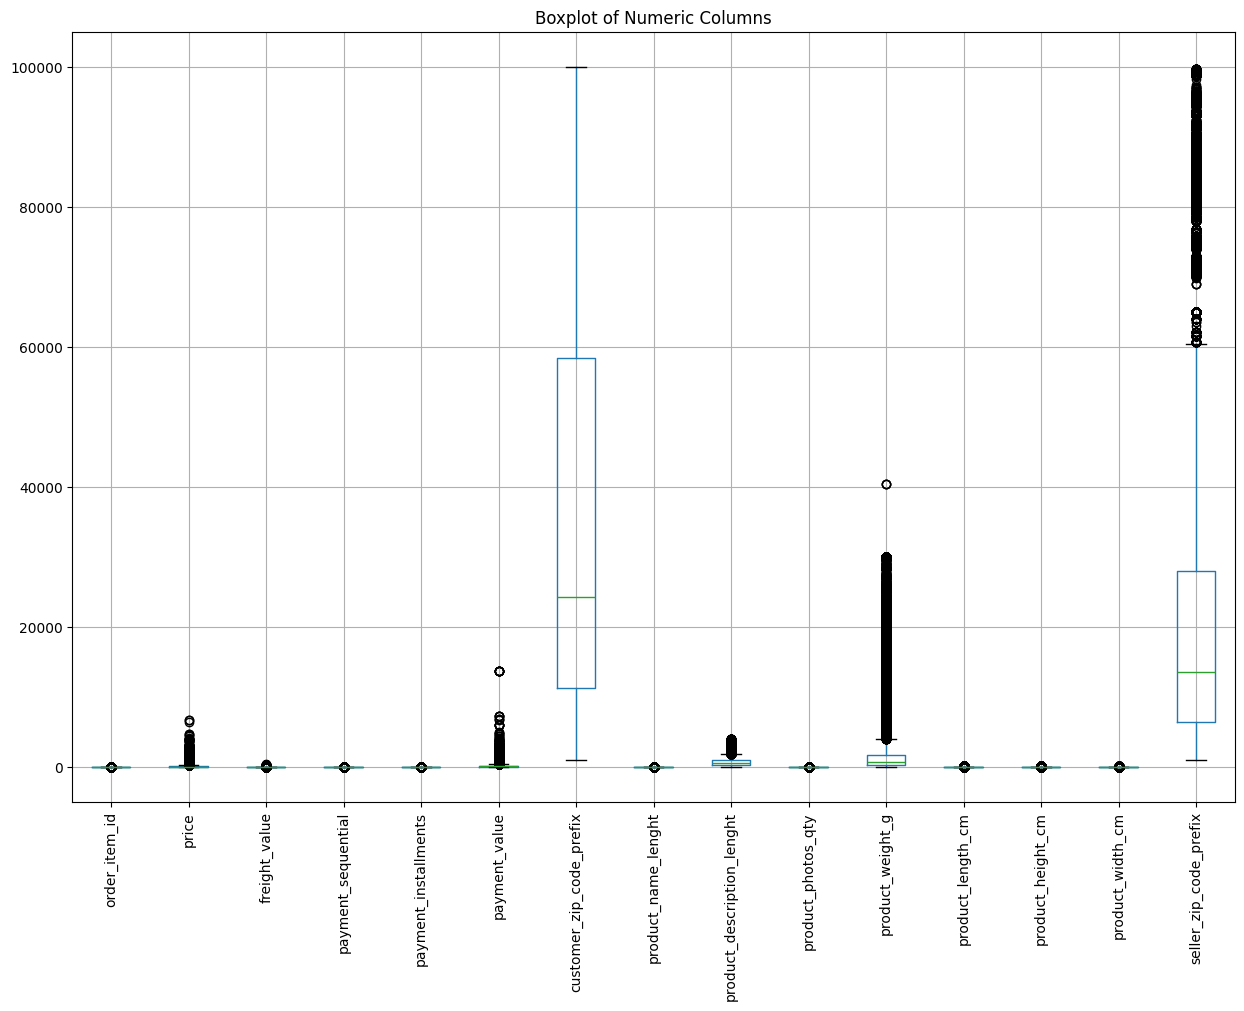

In [150]:
numeric_cols = df_orders_items.select_dtypes(include=[np.number]).columns
# boxplot
plt.figure(figsize=(15, 10))
df_orders_items[numeric_cols].boxplot()
plt.xticks(rotation=90)
plt.title('Boxplot of Numeric Columns')
plt.show()

In [151]:
df_orders_items['payment_type'].value_counts()

,count
payment_type,
credit_card,87286
boleto,23037
voucher,6407
debit_card,1698
not_defined,3


**Insight:**
- Masih terdapat missing values yang harus ditangani mulai dari dengan missing values yang relatif sedikit, contohnya kolom order_approved, relatif sedang seperti order_item_id, dan tinggi seperti product_category_name.
- Terdapat invalid value pada beberapa kolom, misalnya payment_value bernilai 0 padahal order delivered, freight_value bernilai 0 yang bisa jadi error atau promo free shipping, serta product_weight_g bernilai 0 yang jelas saja ini tidak valid. ini wajib ditangani pada tahap cleaning.
- pada kolom price, masih terdapat outlier yang wajib ditangani, outlier ini akan diisi oleh median value sebagai pengganti.
- ditemukan 1659 baris dengan urutan tidak logis (di segmen invalid data) ini akan dihapus di bagian cleaning data

### Cleaning Data

info penting sebelum cleaning. ada status order yakni created, approved shipped, canceled, dan delivered. maka yang bermasalah adalah yang sudah delivered tetapi tidak memiliki informasi item sehingga ini bisa berbahaya.

handle missing value

In [152]:
df_before = df_orders_items[df_orders_items['order_status']=='delivered'].copy()
# membuang baris
df_clean = df_before[df_before['order_item_id'].notna()]
df_clean = df_clean[df_clean['payment_type'].notna()]
print('Ukuran data awal:', df_before.shape[0])
print('Ukuran data setelah:', df_clean.shape[0])
df_clean.head()

Ukuran data awal: 115038
Ukuran data setelah: 115035


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP


menangani missing di product kategori dan yang satu lagi yang berbahasa inggris

In [153]:
df_clean['product_category_name'] = df_clean['product_category_name'].fillna('Unknown')
df_clean['product_category_name_english'] = df_clean['product_category_name_english'].fillna('Unknown')

# df_clean.isnull().sum()

menangani invalid value

In [154]:
invalid_data = df_orders_items[(df_orders_items['order_delivered_customer_date'] < df_orders_items['order_purchase_timestamp'])]
invalid_data2 = df_orders_items[(df_orders_items['order_delivered_carrier_date'] < df_orders_items['order_approved_at'])]
invalid_data3 = df_orders_items[(df_orders_items['order_delivered_customer_date'] < df_orders_items['order_delivered_carrier_date'])]

all_invalid_indices = pd.concat([invalid_data, invalid_data2, invalid_data3]).index

# Filter only the indices that exist in df_clean
existing_invalid_indices = df_clean.index.intersection(all_invalid_indices)

df_clean = df_clean.drop(index=existing_invalid_indices)

print('Ukuran data setelah:', df_clean.shape[0])

Ukuran data setelah: 113385


cek harga dan pembayaran

In [155]:
invalid_price = df_orders_items[df_orders_items['price'] <= 0]
invalid_freight = df_orders_items[df_orders_items['freight_value'] < 0]
invalid_payment = df_orders_items[df_orders_items['payment_value'] <= 0]
invalid_photo = df_clean[df_clean['product_photos_qty'] < 0]

all_invalid_data = pd.concat([invalid_price, invalid_freight, invalid_payment, invalid_photo]).index

# Filter only the indices that exist in df_clean
existing_invalid_data = df_clean.index.intersection(all_invalid_data)

df_clean = df_clean.drop(index=existing_invalid_data)

print('Ukuran data setelah:', df_clean.shape[0])

Ukuran data setelah: 113381


invalid installments & item id


In [156]:
invalid_installments = df_clean[df_clean['payment_installments'] < 0]
invalid_item_id = df_clean[df_clean['order_item_id'] < 0]

print(len(invalid_installments), len(invalid_item_id))

0 0


memastikan semua kolom tanggal bertipe datetime

In [157]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col])

# df_clean.info()


In [158]:
dup_rows = df_clean[df_clean.duplicated(subset=['order_id','order_item_id'], keep=False)]
dup_rows[['order_id','order_item_id','payment_sequential','payment_type','payment_value']].head(20)


,order_id,order_item_id,payment_sequential,payment_type,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,1.0,1.0,credit_card,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,1.0,3.0,voucher,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,1.0,2.0,voucher,18.59
11,e69bfb5eb88e0ed6a785585b27e16dbf,1.0,2.0,voucher,161.42
12,e69bfb5eb88e0ed6a785585b27e16dbf,1.0,1.0,credit_card,8.34
23,83018ec114eee8641c97e08f7b4e926f,1.0,2.0,voucher,62.15
24,83018ec114eee8641c97e08f7b4e926f,1.0,3.0,voucher,24.86
25,83018ec114eee8641c97e08f7b4e926f,1.0,1.0,credit_card,5.96
96,634e8f4c0f6744a626f77f39770ac6aa,1.0,2.0,voucher,227.20
97,634e8f4c0f6744a626f77f39770ac6aa,1.0,1.0,credit_card,7.08


**Insight:**
- Data lebih rapi, konsisten, dan siap untuk analisis lanjutan
- Tidak ada noise yyang bisa mengganggu visualisasi

## Exploratory Data Analysis (EDA)

### Explore ...

In [159]:
# Analisis produk dan kategori paling sering dibeli di setiap wilayah (customer_state)

# Grouping berdasarkan customer_state dan product_category_name_english untuk mencari kategori populer
most_frequent_categories_by_state = df_clean.groupby(['customer_state', 'product_category_name_english']).size().reset_index(name='purchase_count')

# Mendapatkan kategori teratas untuk setiap wilayah
top_categories_per_state = most_frequent_categories_by_state.loc[most_frequent_categories_by_state.groupby('customer_state')['purchase_count'].idxmax()]

print("Top Product Category by Purchase Count in Each State:")
display(top_categories_per_state.head(10))

# Grouping berdasarkan customer_state dan product_id untuk mencari produk populer
most_frequent_products_by_state = df_clean.groupby(['customer_state', 'product_id', 'product_category_name_english']).size().reset_index(name='purchase_count')

# Mendapatkan produk teratas untuk setiap wilayah
top_products_per_state = most_frequent_products_by_state.loc[most_frequent_products_by_state.groupby('customer_state')['purchase_count'].idxmax()]

print("\nTop Product by Purchase Count in Each State:")
display(top_products_per_state.head(10))

Top Product Category by Purchase Count in Each State:


,customer_state,product_category_name_english,purchase_count
13,AC,furniture_decor,12
52,AL,health_beauty,63
91,AM,health_beauty,21
121,AP,health_beauty,10
168,BA,health_beauty,380
223,CE,health_beauty,165
281,DF,health_beauty,243
313,ES,bed_bath_table,236
372,GO,bed_bath_table,237
456,MA,health_beauty,88



Top Product by Purchase Count in Each State:


,customer_state,product_id,product_category_name_english,purchase_count
58,AC,b81a05d0dd312ece2140846909f5ef81,furniture_decor,6
236,AL,6cdd53843498f92890544667809f1595,health_beauty,8
446,AM,0829c25b4a3efca7651f07cd4b8e05bc,computers_accessories,4
609,AP,68d9c8a95d2b7cb57efe9e1e929bdd6a,fixed_telephony,5
1307,BA,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,21
3982,CE,bb50f2e236e5eea0100680137654686c,health_beauty,26
4782,DF,4c2394abfbac7ff59ec7a420918562fa,health_beauty,17
6505,ES,53759a2ecddad2bb87a079a1f1519f73,garden_tools,14
8534,GO,9571759451b1d780ee7c15012ea109d4,auto,20
9722,MA,bb50f2e236e5eea0100680137654686c,health_beauty,9


In [160]:
# 1. Menghitung volume transaksi per wilayah (customer_state)
transaction_volume_by_state = df_clean['customer_state'].value_counts().reset_index()
transaction_volume_by_state.columns = ['customer_state', 'transaction_volume']

# 2. Menghitung total penjualan (payment_value) per wilayah (customer_state)
total_sales_by_state = df_clean.groupby('customer_state')['payment_value'].sum().reset_index()
total_sales_by_state.columns = ['customer_state', 'total_sales']

# 3. Menggabungkan data volume transaksi dan total penjualan
regional_analysis = pd.merge(transaction_volume_by_state, total_sales_by_state, on='customer_state')

# 4. Menghitung persentase kontribusi terhadap total penjualan global
total_global_sales = regional_analysis['total_sales'].sum()
regional_analysis['sales_contribution_percentage'] = (regional_analysis['total_sales'] / total_global_sales) * 100

# 5. Mengurutkan berdasarkan volume transaksi tertinggi
regional_analysis = regional_analysis.sort_values(by='transaction_volume', ascending=False)

# Menampilkan hasil analisis regional (10 teratas)
display(regional_analysis.head(10))

,customer_state,transaction_volume,total_sales,sales_contribution_percentage
0,SP,47817,7304168.05,37.441521
1,RJ,14699,2657884.83,13.624447
2,MG,13213,2249714.22,11.532145
3,RS,6277,1091601.06,5.595600
4,PR,5776,1015404.61,5.205013
5,SC,4156,757684.46,3.883927
6,BA,3877,765620.96,3.924610
7,DF,2377,412775.98,2.115910
8,GO,2332,485759.02,2.490024
9,ES,2278,393460.11,2.016896


**Insight dari EDA:**

- **Distribusi Regional:** Wilayah **SP (Sao Paulo)** merupakan kontributor terbesar baik dari segi volume transaksi maupun total nilai penjualan, diikuti oleh RJ dan MG. Hal ini menunjukkan konsentrasi pasar yang kuat di wilayah Tenggara Brasil.
- **Kategori Populer:** Kategori seperti *health_beauty* dan *bed_bath_table* mendominasi jumlah pembelian di sebagian besar wilayah, yang menandakan kategori ini adalah kebutuhan pokok bagi pelanggan e-commerce.
- **Volume vs Nilai:** Terdapat korelasi positif yang kuat antara volume transaksi dan total pendapatan di setiap negara bagian. Namun, wilayah dengan volume lebih rendah tetap berkontribusi secara signifikan jika harga rata-rata produk yang dibeli lebih tinggi.
- **Produk Spesifik:** Melalui analisis `product_id`, kita dapat melihat produk tertentu yang menjadi 'top seller' di negara bagian tertentu, memungkinkan strategi pemasaran berbasis lokasi yang lebih personal.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Produk dan kategori produk apa yang menghasilkan total pendapatan tertinggi?


/tmp/ipykernel_160/1528650451.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index, palette='viridis')


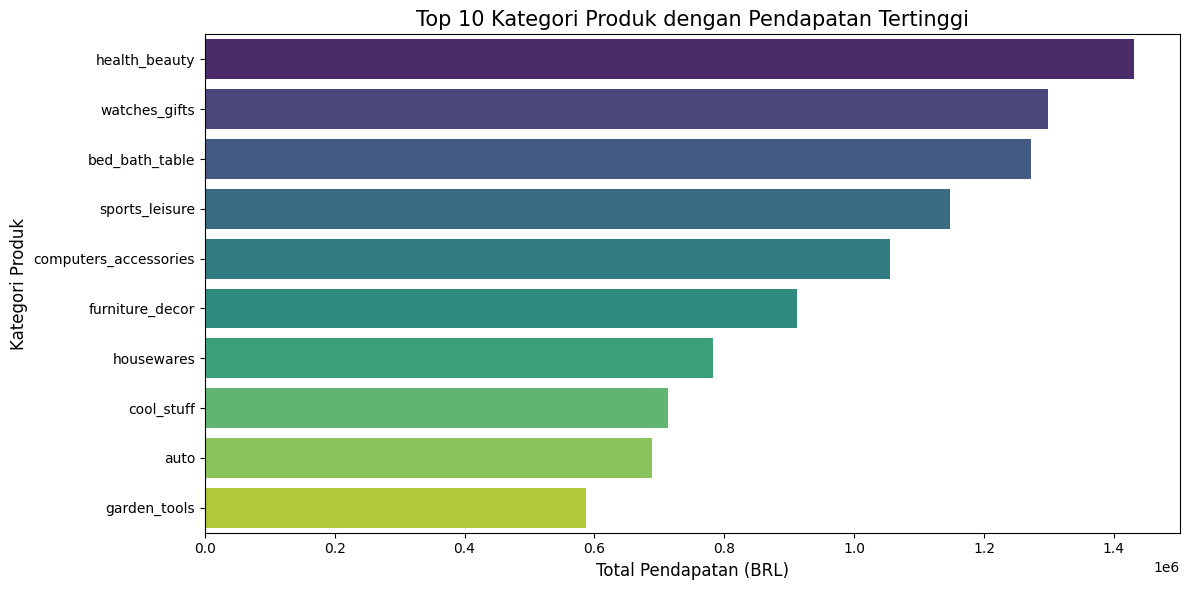

In [161]:
# Visualisasi Pertanyaan 1: Top 10 Kategori Produk berdasarkan Total Pendapatan

# Menghitung total pendapatan (price + freight) per kategori
df_clean['total_revenue'] = df_clean['price'] + df_clean['freight_value']
revenue_by_category = df_clean.groupby('product_category_name_english')['total_revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index, palette='viridis')
plt.title('Top 10 Kategori Produk dengan Pendapatan Tertinggi', fontsize=15)
plt.xlabel('Total Pendapatan (BRL)', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Produk dan kategori produk apa yang paling sering dibeli pada masing masing wilayah?


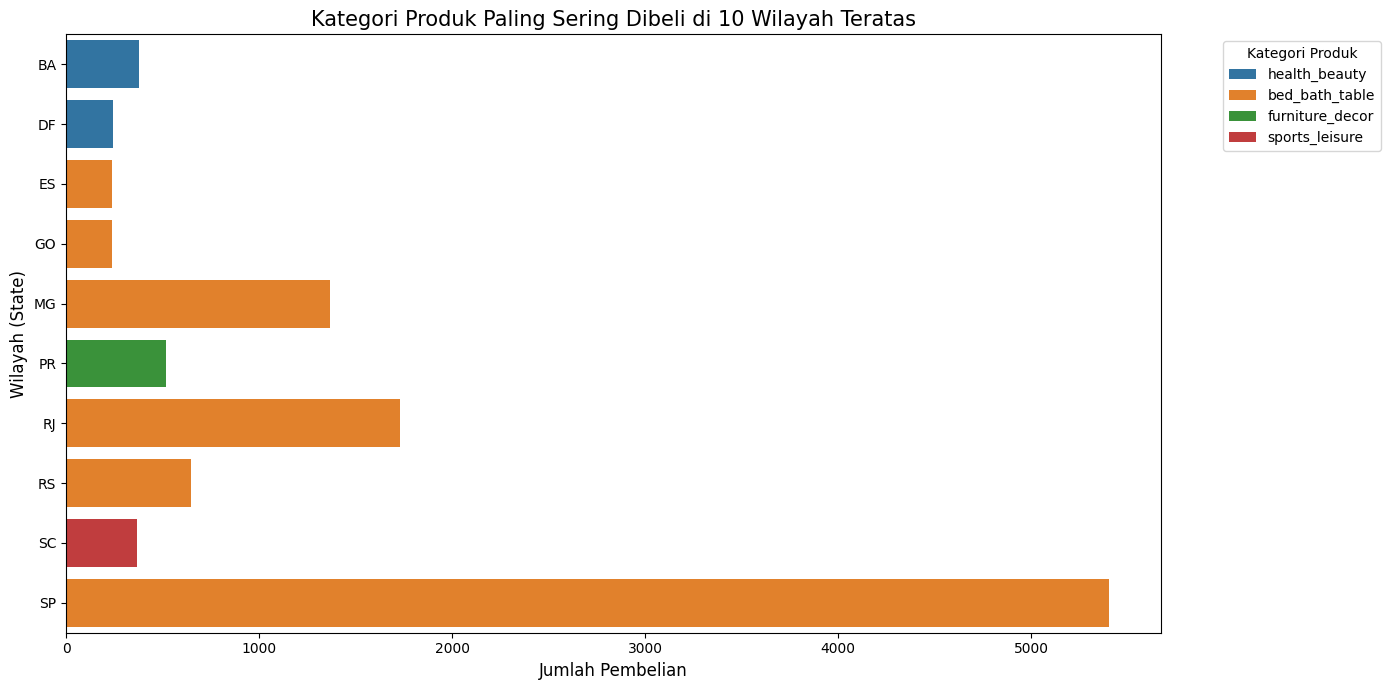

In [162]:
# Visualisasi Pertanyaan 2: Kategori Produk yang paling sering dibeli di 10 Wilayah Teratas

# Mencari kategori terpopuler per wilayah
state_category_counts = df_clean.groupby(['customer_state', 'product_category_name_english']).size().reset_index(name='purchase_count')
top_cat_per_state = state_category_counts.loc[state_category_counts.groupby('customer_state')['purchase_count'].idxmax()]

# Mengambil 10 wilayah dengan volume transaksi tertinggi untuk visualisasi yang lebih bersih
top_10_states = df_clean['customer_state'].value_counts().head(10).index
filtered_top_cat = top_cat_per_state[top_cat_per_state['customer_state'].isin(top_10_states)]

plt.figure(figsize=(14, 7))
sns.barplot(x='purchase_count', y='customer_state', hue='product_category_name_english', data=filtered_top_cat, palette='tab10')
plt.title('Kategori Produk Paling Sering Dibeli di 10 Wilayah Teratas', fontsize=15)
plt.xlabel('Jumlah Pembelian', fontsize=12)
plt.ylabel('Wilayah (State)', fontsize=12)
plt.legend(title='Kategori Produk', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Pertanyaan 3:**

/tmp/ipykernel_160/3112556887.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='transaction_volume', y='customer_state', data=top_10_regional, palette='magma', ax=ax[0])
/tmp/ipykernel_160/3112556887.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sales_contribution_percentage', y='customer_state', data=top_10_regional, palette='coolwarm', ax=ax[1])


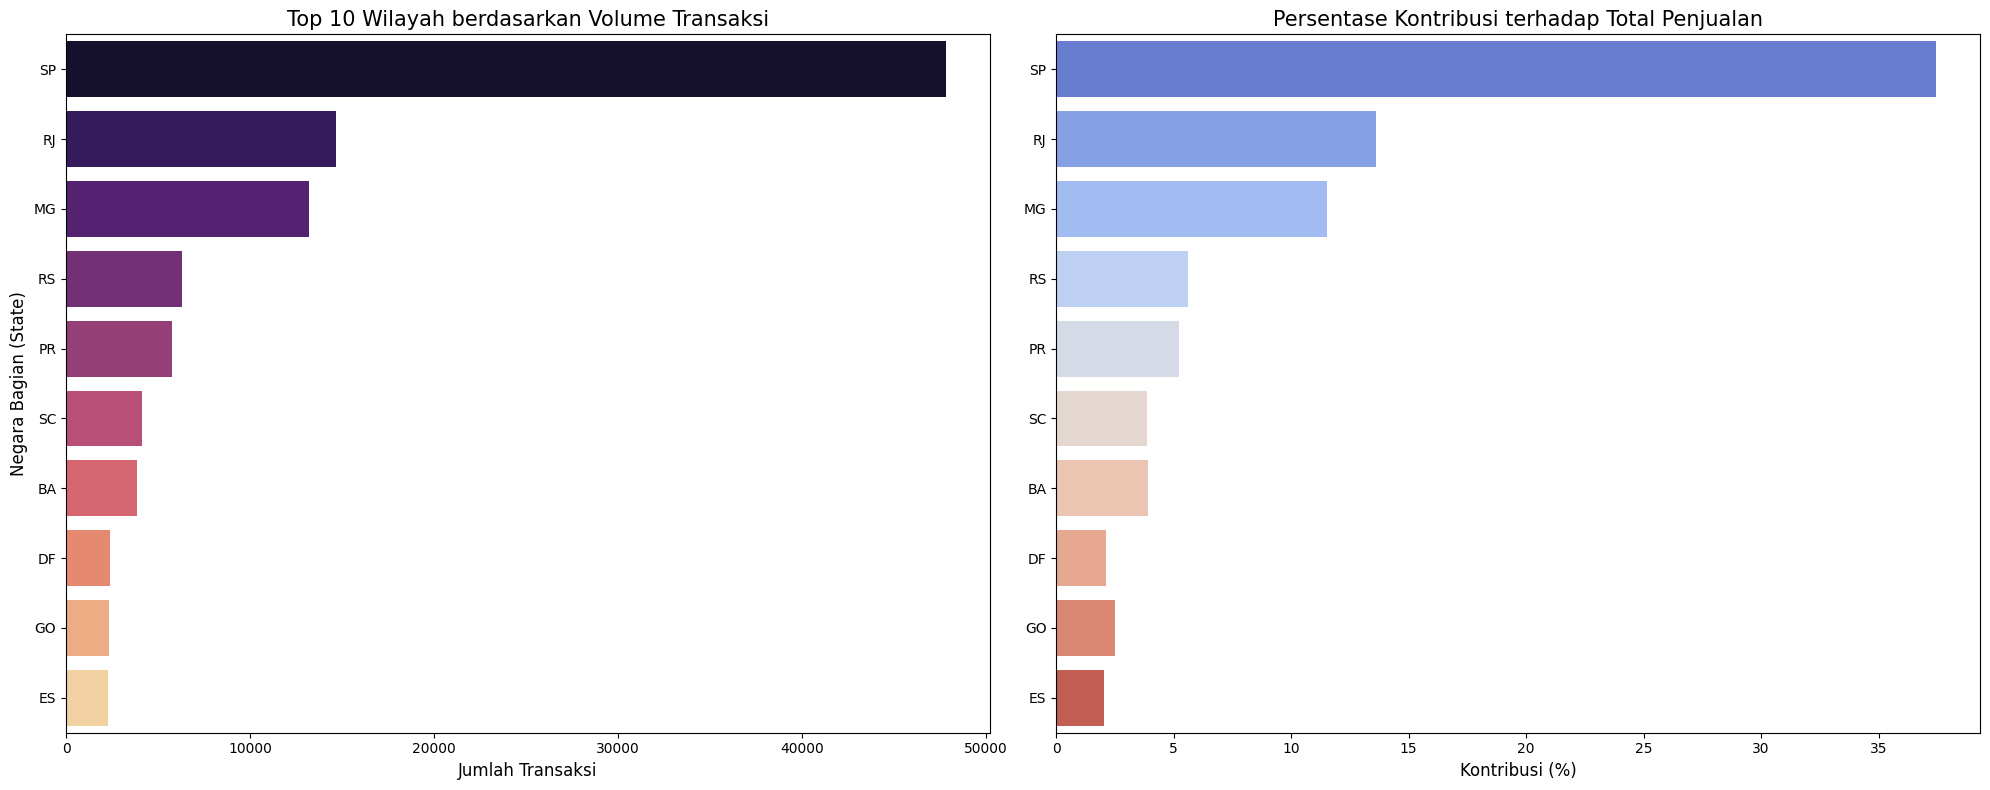

In [163]:
# Visualisasi Pertanyaan 3: Volume Transaksi dan Kontribusi Penjualan per Wilayah

# 1. Menyiapkan data 10 wilayah teratas berdasarkan volume transaksi
top_10_regional = regional_analysis.head(10)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

# Plot Volume Transaksi
sns.barplot(x='transaction_volume', y='customer_state', data=top_10_regional, palette='magma', ax=ax[0])
ax[0].set_title('Top 10 Wilayah berdasarkan Volume Transaksi', fontsize=15)
ax[0].set_xlabel('Jumlah Transaksi', fontsize=12)
ax[0].set_ylabel('Negara Bagian (State)', fontsize=12)

# Plot Persentase Kontribusi Penjualan
sns.barplot(x='sales_contribution_percentage', y='customer_state', data=top_10_regional, palette='coolwarm', ax=ax[1])
ax[1].set_title('Persentase Kontribusi terhadap Total Penjualan', fontsize=15)
ax[1].set_xlabel('Kontribusi (%)', fontsize=12)
ax[1].set_ylabel('', fontsize=12)

plt.tight_layout()
plt.show()

**Insight:**
- **Kategori Premium:** Meskipun volume penjualan mungkin bervariasi, kategori seperti *health_beauty*, *watches_gifts*, dan *bed_bath_table* menghasilkan pendapatan tertinggi. Hal ini menunjukkan kombinasi antara volume transaksi yang sehat dan nilai produk yang cukup tinggi.
- **Kontributor Utama:** Sektor kesehatan, kecantikan, dan perlengkapan rumah tangga merupakan pilar utama pendapatan platform, mengungguli kategori teknis seperti aksesoris komputer.
- **Dominasi Kategori Tertentu:** Kategori *bed_bath_table* dan *health_beauty* secara konsisten muncul sebagai kategori yang paling sering dibeli di hampir semua wilayah teratas (seperti SP, MG, RJ).
- **Variasi Regional:** Meskipun ada kategori yang dominan secara umum, beberapa wilayah menunjukkan minat spesifik, seperti *furniture_decor* yang sangat kuat di wilayah PR.
- **Konsistensi Pasar:** Konsistensi kategori populer di berbagai negara bagian menunjukkan bahwa strategi inventaris untuk produk rumah tangga dan kesehatan dapat diterapkan secara seragam di pasar-pasar utama.
- **Dominasi Sao Paulo (SP):** Wilayah SP tidak hanya memiliki volume transaksi tertinggi, tetapi juga memberikan kontribusi lebih dari sepertiga total pendapatan perusahaan. Ini menunjukkan ketergantungan pasar yang besar pada wilayah ini.
- **Wilayah Pendukung Utama:** RJ (Rio de Janeiro) dan MG (Minas Gerais) secara konsisten menempati posisi kedua dan ketiga, mempertegas bahwa pasar utama terkonsentrasi di wilayah Tenggara Brasil.
- **Potensi Wilayah Lain:** Meskipun volume transaksi di negara bagian seperti RS, PR, dan SC lebih rendah, mereka tetap memberikan kontribusi persentase penjualan yang signifikan, yang menunjukkan daya beli per transaksi di sana cukup stabil.

## Analisis Lanjutan (Opsional)

RFM (Recency, Frequency, Monetary) Analysis:
- Recency: Kapan terakhir kali pelanggan melakukan transaksi?
- Frequency: Seberapa sering pelanggan berbelanja?
- Monetary: Berapa banyak uang yang dihabiskan pelanggan?


RFM Analysis Table (Top 5 Customers):


,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89


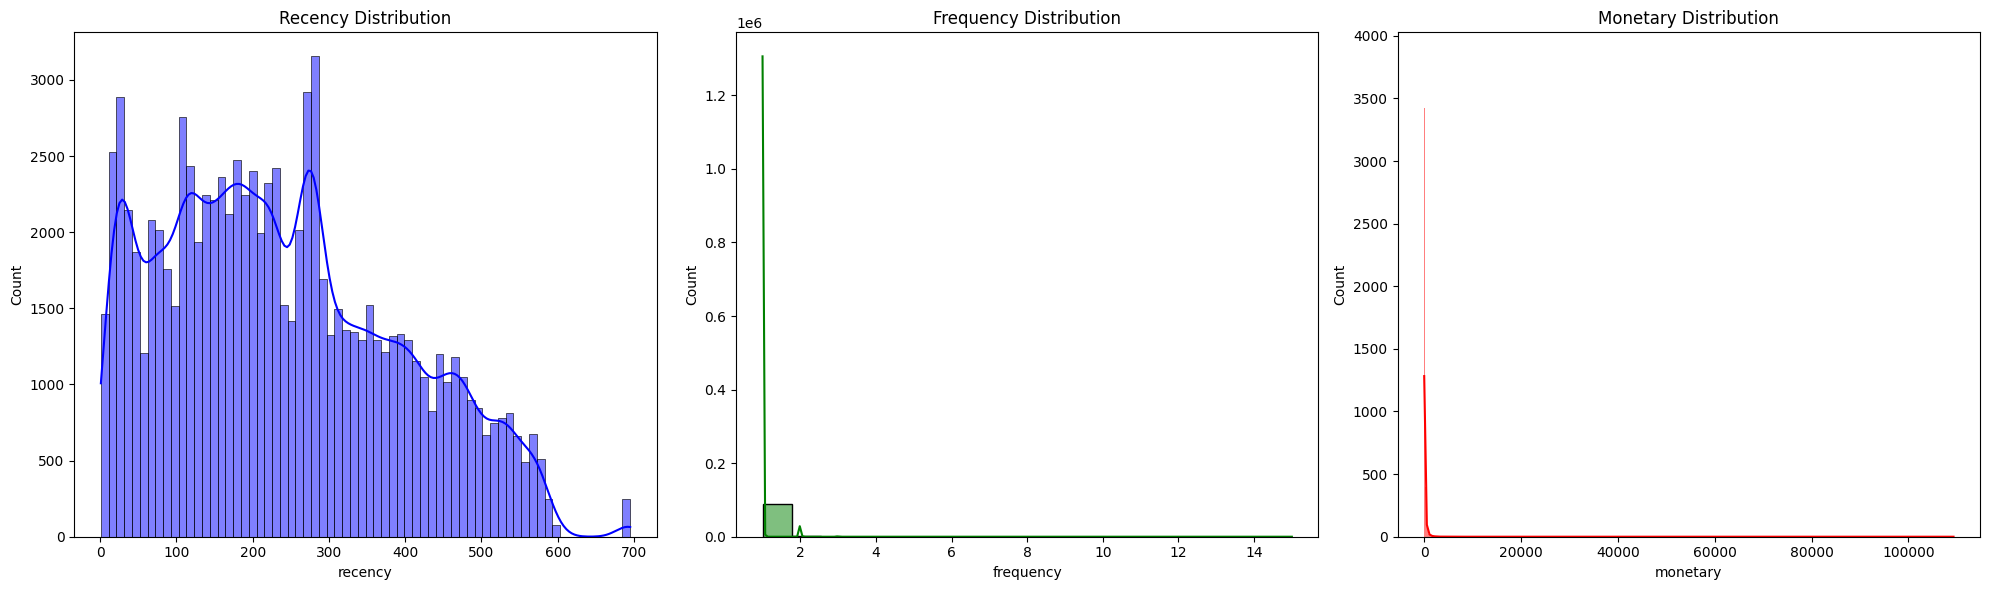

In [164]:
# Analisis Lanjutan: RFM Analysis

# Menghitung tanggal transaksi terakhir (Recency)
# Kita asumsikan 'hari ini' adalah satu hari setelah tanggal transaksi terakhir di dataset
recent_date = df_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = df_clean.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days,  # Recency
    'order_id': 'nunique',                                             # Frequency
    'payment_value': 'sum'                                             # Monetary
})

rfm_df.rename(columns={
    'order_purchase_timestamp': 'recency',
    'order_id': 'frequency',
    'payment_value': 'monetary'
}, inplace=True)

print("RFM Analysis Table (Top 5 Customers):")
display(rfm_df.head())

# Distribusi RFM
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

sns.histplot(rfm_df['recency'], kde=True, ax=ax[0], color='blue')
ax[0].set_title('Recency Distribution')

sns.histplot(rfm_df['frequency'], kde=True, ax=ax[1], color='green')
ax[1].set_title('Frequency Distribution')

sns.histplot(rfm_df['monetary'], kde=True, ax=ax[2], color='red')
ax[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

## Conclusion

**Kesimpulan Analisis RFM:**

- **Recency:** Distribusi menunjukkan kapan pelanggan terakhir kali bertransaksi. Terdapat variasi yang cukup besar, namun penting untuk mengidentifikasi pelanggan yang sudah lama tidak aktif untuk program *re-engagement*.
- **Frequency:** Terlihat jelas bahwa sebagian besar pelanggan baru melakukan **satu kali transaksi** (frekuensi = 1). Strategi retensi pelanggan sangat diperlukan untuk mendorong pembelian kedua dan seterusnya.
- **Monetary:** Nilai transaksi didominasi oleh pembelian bernilai rendah hingga menengah. Terdapat segmen kecil pelanggan bernilai tinggi yang berkontribusi besar pada pendapatan, yang perlu diberikan perlakuan khusus (loyalty program).

**Strategi Bisnis:** Fokus pada konversi pelanggan 'One-time buyer' menjadi pelanggan tetap dan berikan promosi khusus untuk wilayah dengan nilai *monetary* yang tinggi.